In [1]:
import pandas as pd
import numpy as np

import tubesml as tml

import matplotlib.pyplot as plt
%matplotlib inline

from source.aggregated_stats import process_details, full_stats
from source.add_info import add_seed, add_elo, add_stage, add_quality
from source.make_train_test import make_teams_target, make_training_data


In [2]:
men_training = pd.read_csv('data/processed/men_training.csv')
men_training["tourney"] = 1

women_training = pd.read_csv('data/processed/women_training.csv')
women_training["tourney"] = 0

full_training = pd.concat([men_training, women_training], ignore_index=True)

full_training.to_csv("data/processed/full_training.csv", index=False)
full_training.head()

,Season,DayNum,Team1,Team2,target,target_points,T1_Loc,T2_Loc,ID,T1_Ast,...,stage_Round2,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible,T1_quality,T2_quality,delta_quality,tourney
0,2003,136,1112,1436,1,29,0,0,2003_1112_1436,17.488095,...,False,False,False,False,False,False,42.710561,0.650237,42.060324,1
1,2003,136,1113,1272,1,13,0,0,2003_1113_1272,15.448276,...,False,False,False,False,False,False,7.704377,12.577559,-4.873181,1
2,2003,136,1141,1166,1,6,0,0,2003_1141_1166,15.620690,...,False,False,False,False,False,False,4.880807,13.600178,-8.719372,1
3,2003,136,1143,1301,1,2,0,0,2003_1143_1301,15.816092,...,False,False,False,False,False,False,10.200473,6.628850,3.571623,1
4,2003,136,1140,1163,0,-5,0,0,2003_1140_1163,13.372760,...,False,False,False,False,False,False,8.352330,8.473791,-0.121461,1


# Winning target

In [3]:
target = "target"
col_to_use = [c for c in full_training if "target" not in c and c != "ID" and "region" not in c] + [target]

df = full_training[col_to_use].copy()

to_drop = ["delta_def_rating_diff", "delta_impact_diff", "T1_def_rating_diff", "T2_def_rating_diff"]
df = df.drop(to_drop, axis=1)

df.sample(5)

,Season,DayNum,Team1,Team2,T1_Loc,T2_Loc,T1_Ast,T1_Ast_TO_ratio,T1_Ast_TO_ratio_diff,T1_Ast_diff,...,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible,T1_quality,T2_quality,delta_quality,tourney,target
1406,2003,137,1280,1139,0,0,14.407407,0.984678,0.303368,4.525926,...,False,False,False,False,False,12.469813,7.774515,4.695297,1,0
2504,2021,140,1325,1166,0,0,17.636364,1.787812,0.785602,3.954545,...,False,False,False,False,False,1.058206,17.669842,-16.611636,1,0
1381,2025,144,1246,1397,0,0,16.791246,1.894053,-0.275981,4.060606,...,True,False,False,False,False,170.709672,395.611512,-224.901840,1,0
2706,2024,144,1345,1211,0,0,18.205387,1.823714,-0.019402,3.993266,...,True,False,False,False,False,93.923589,18.519159,75.404430,1,1
3348,2019,137,3163,3406,1,-1,19.787879,1.969306,1.107064,8.969697,...,False,False,False,False,False,564.371758,1.191979,563.179779,0,1


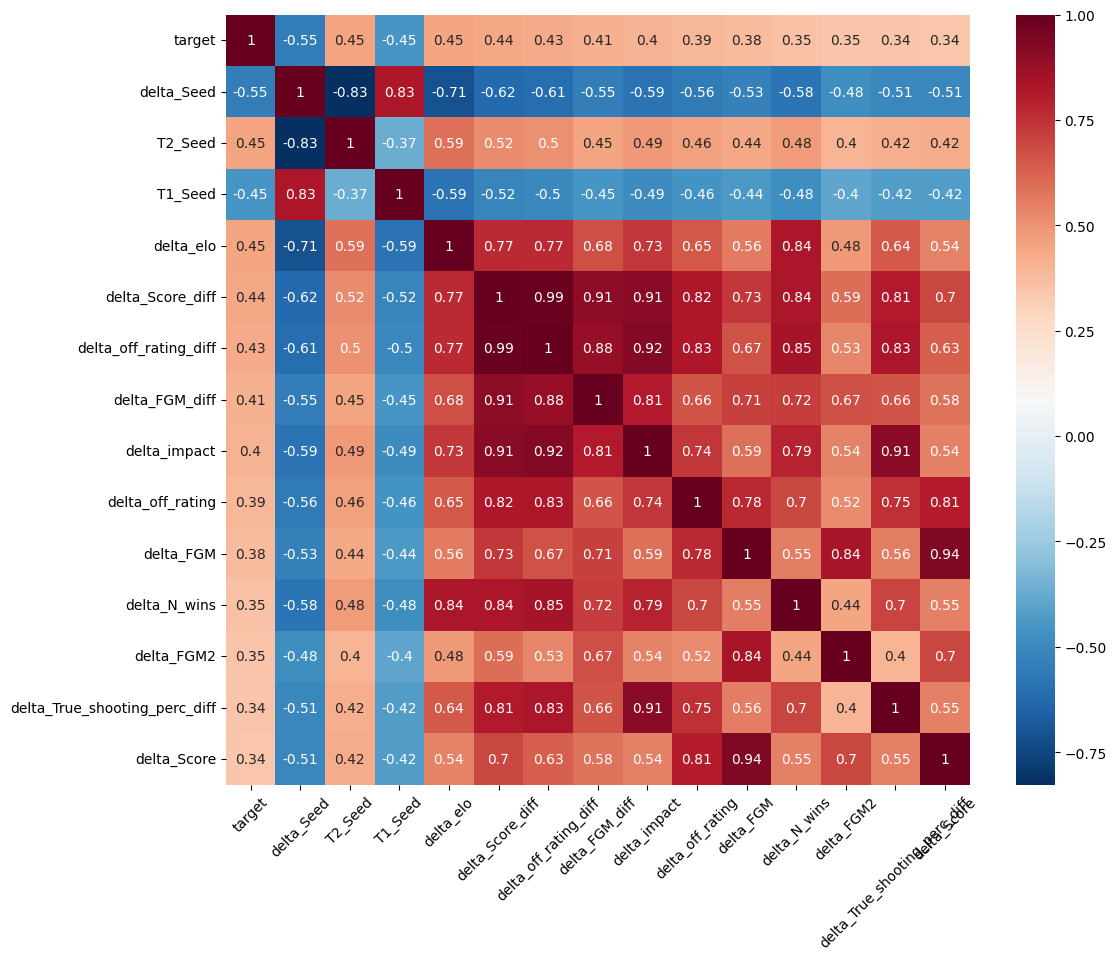

In [4]:
high_corr = tml.plot_correlations(data=df, target=target, limit=15, annot=True)

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN be

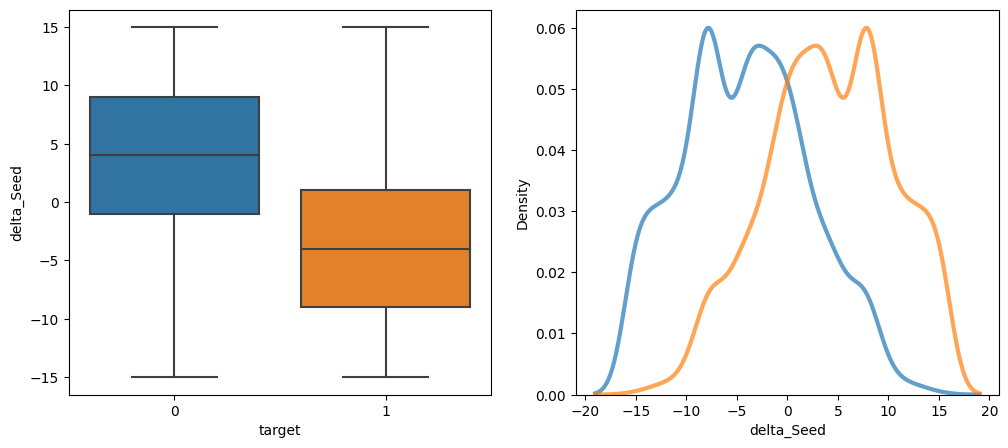

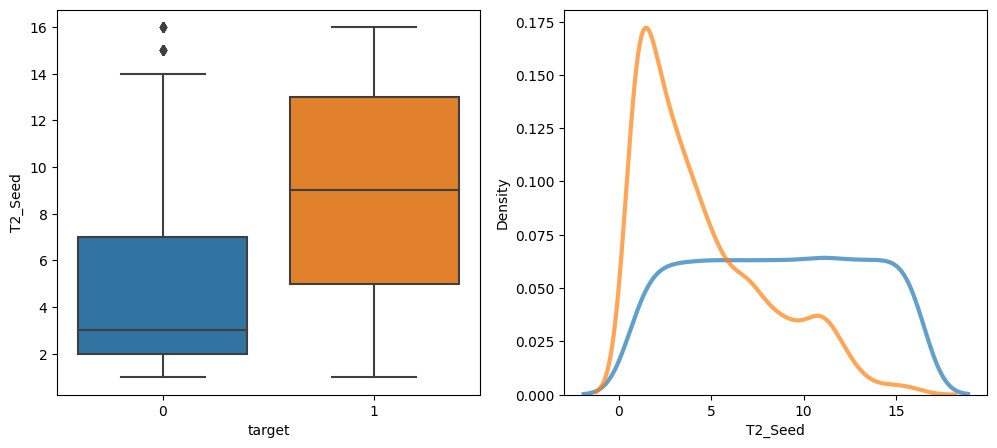

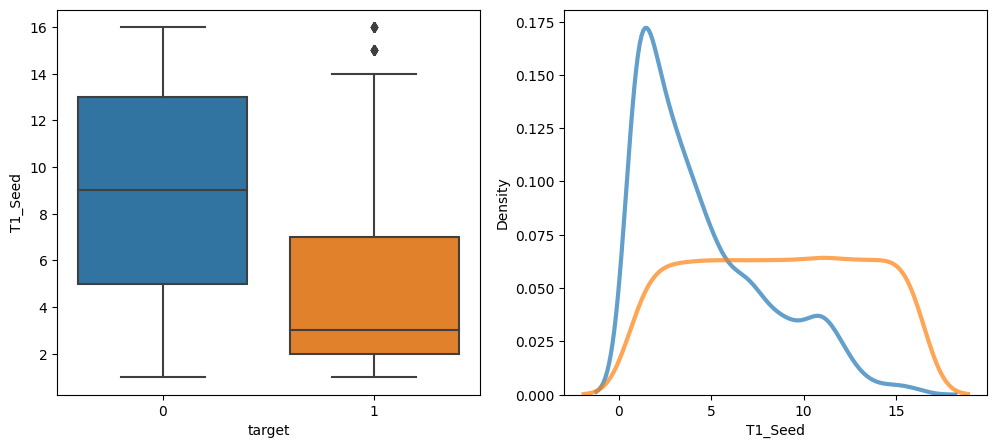

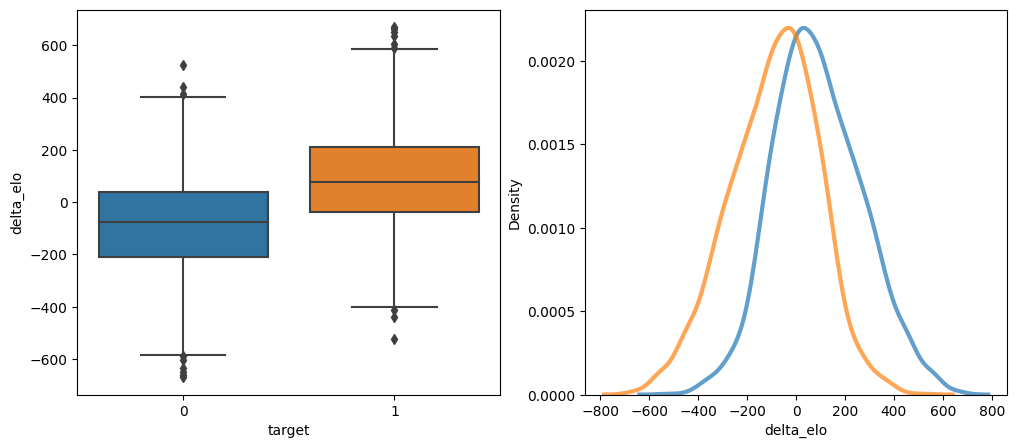

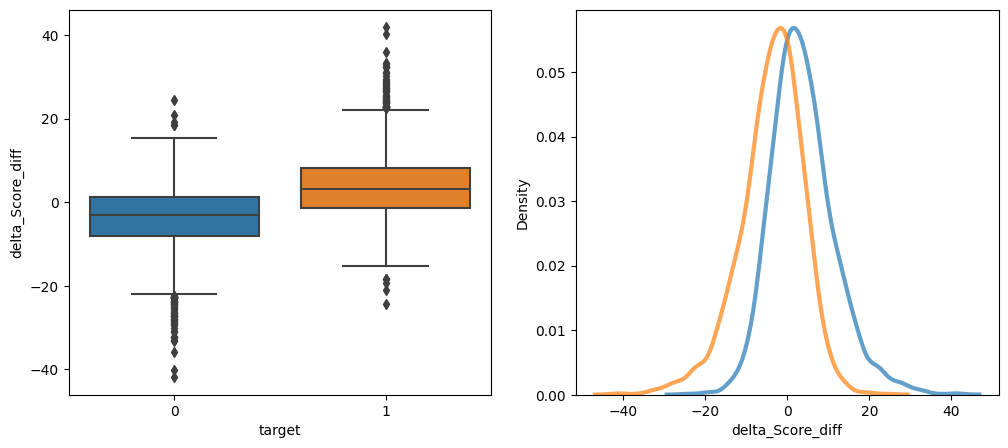

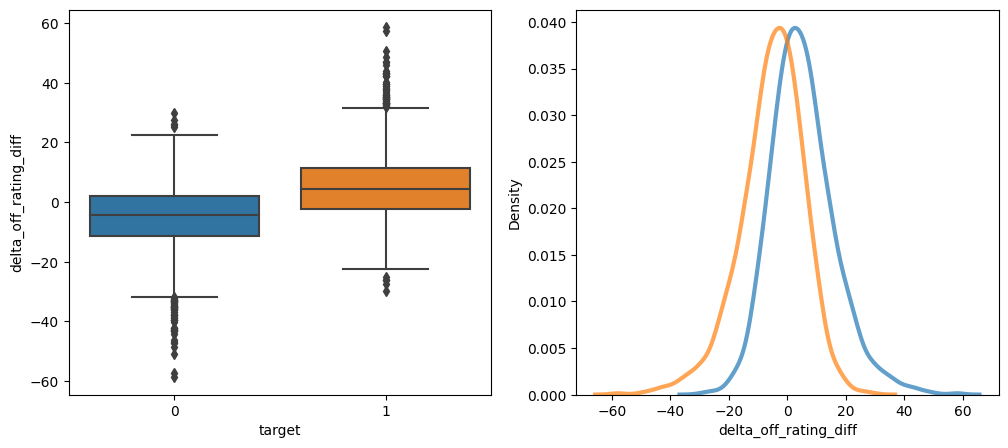

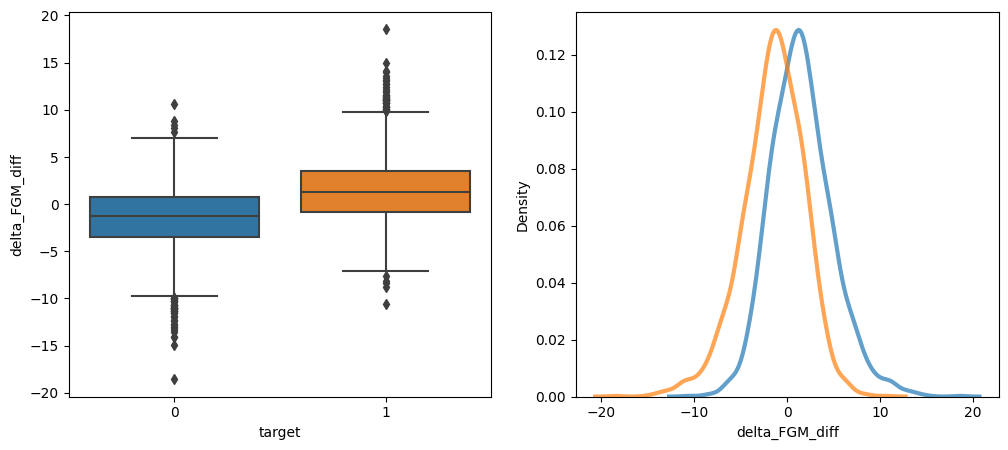

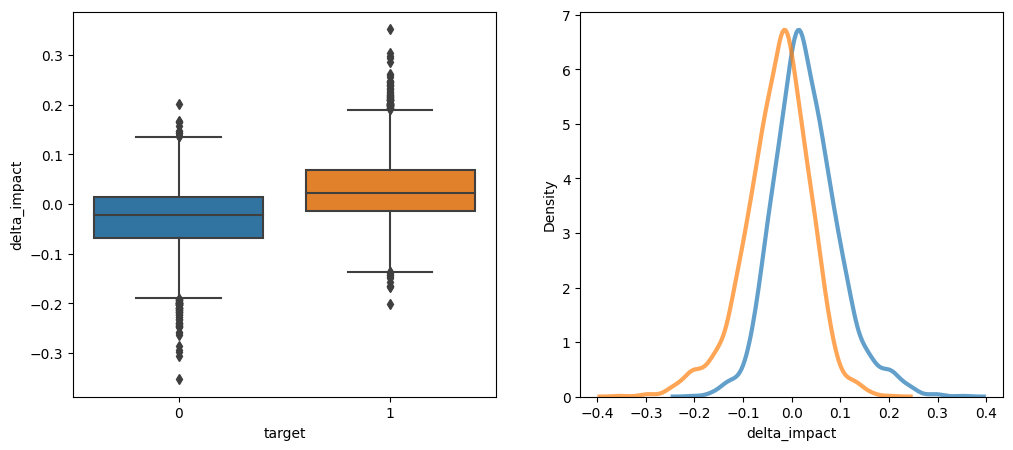

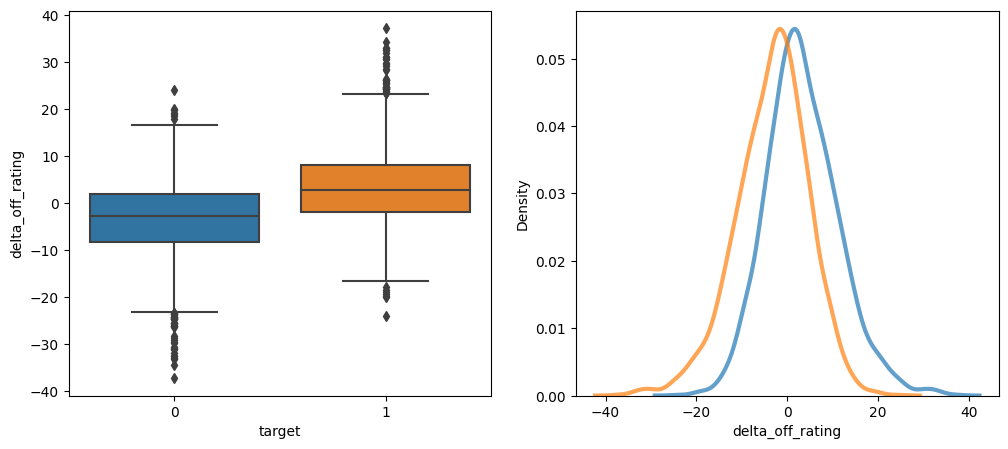

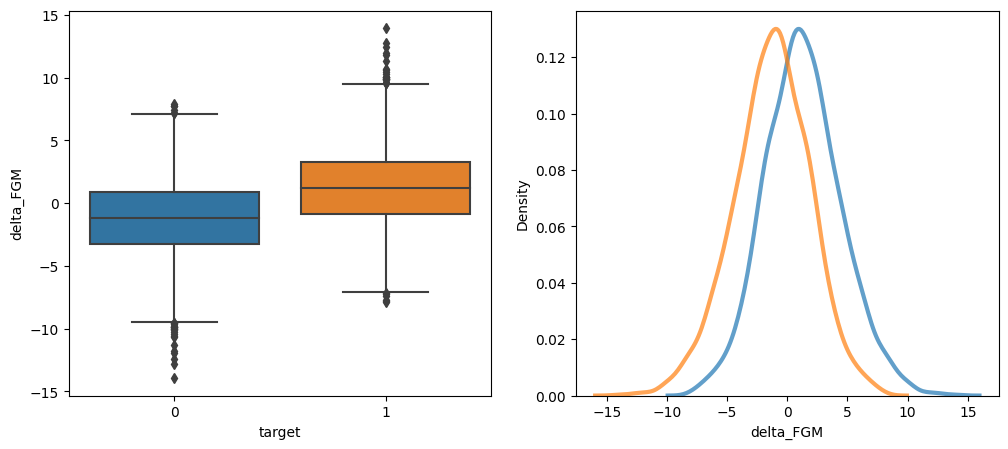

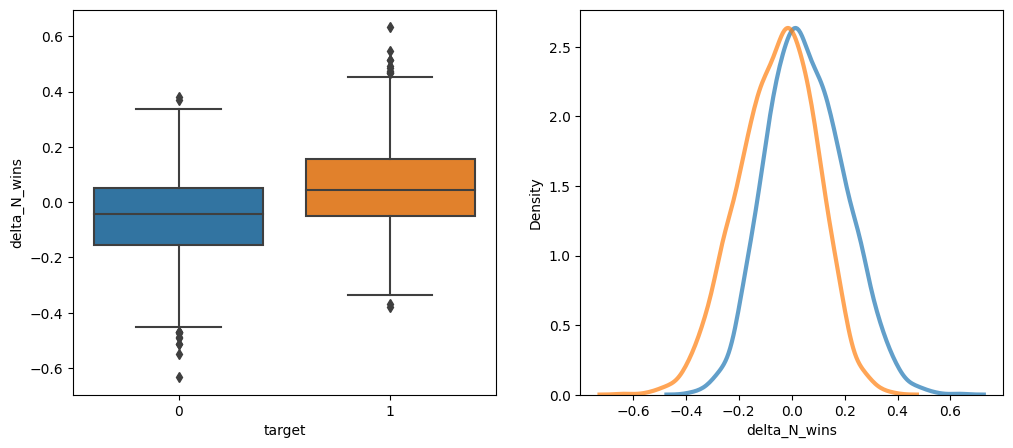

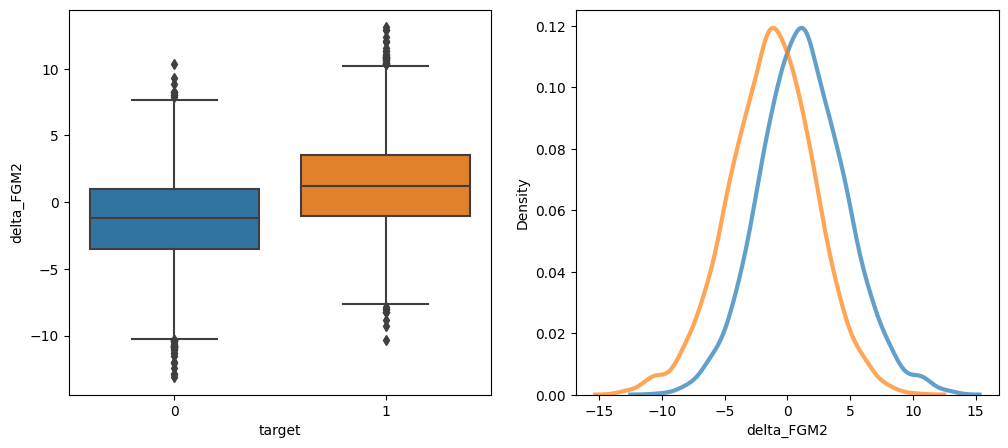

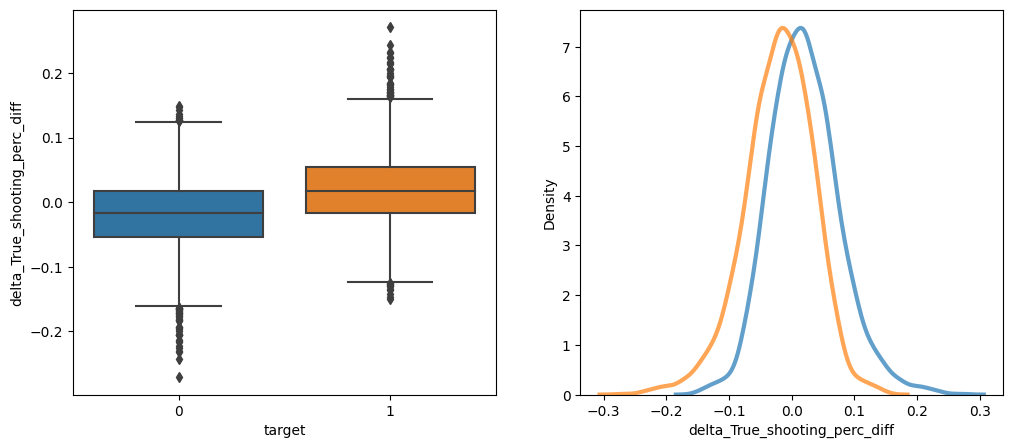

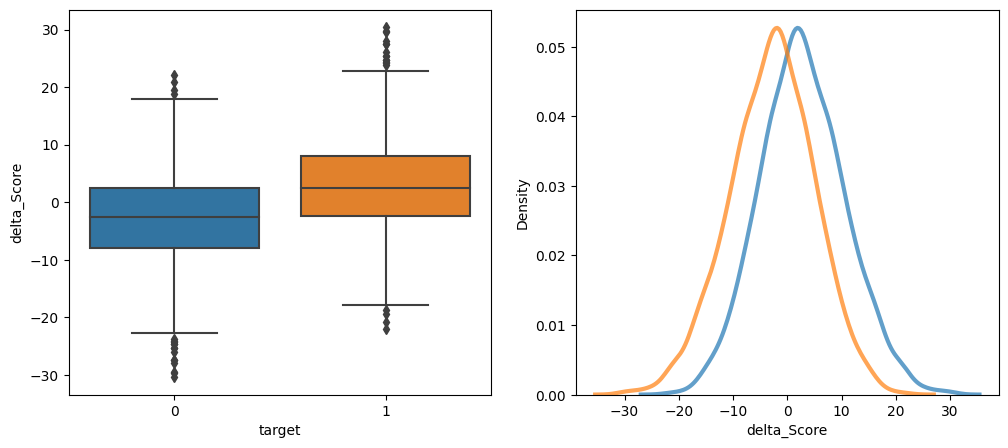

In [5]:
for col in high_corr.index:
    if col == target:
        continue
    tml.segm_target(data=df, cat=target, target=col)

# Point difference

In [6]:
target = "target_points"
col_to_use = [c for c in full_training if "target" not in c and c != "ID" and "region" not in c] + [target]

df = full_training[col_to_use].copy()
to_drop = ["delta_def_rating_diff", "delta_impact_diff", "T1_def_rating_diff", "T2_def_rating_diff"]
df = df.drop(to_drop, axis=1)

df.head()

,Season,DayNum,Team1,Team2,T1_Loc,T2_Loc,T1_Ast,T1_Ast_TO_ratio,T1_Ast_TO_ratio_diff,T1_Ast_diff,...,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible,T1_quality,T2_quality,delta_quality,tourney,target_points
0,2003,136,1112,1436,0,0,17.488095,1.293488,0.268766,2.146825,...,False,False,False,False,False,42.710561,0.650237,42.060324,1,29
1,2003,136,1113,1272,0,0,15.448276,1.203241,0.234362,1.501916,...,False,False,False,False,False,7.704377,12.577559,-4.873181,1,13
2,2003,136,1141,1166,0,0,15.620690,0.876115,0.085721,3.827586,...,False,False,False,False,False,4.880807,13.600178,-8.719372,1,6
3,2003,136,1143,1301,0,0,15.816092,1.223071,0.068819,-0.065134,...,False,False,False,False,False,10.200473,6.628850,3.571623,1,2
4,2003,136,1140,1163,0,0,13.372760,1.089304,0.287913,2.684588,...,False,False,False,False,False,8.352330,8.473791,-0.121461,1,-5


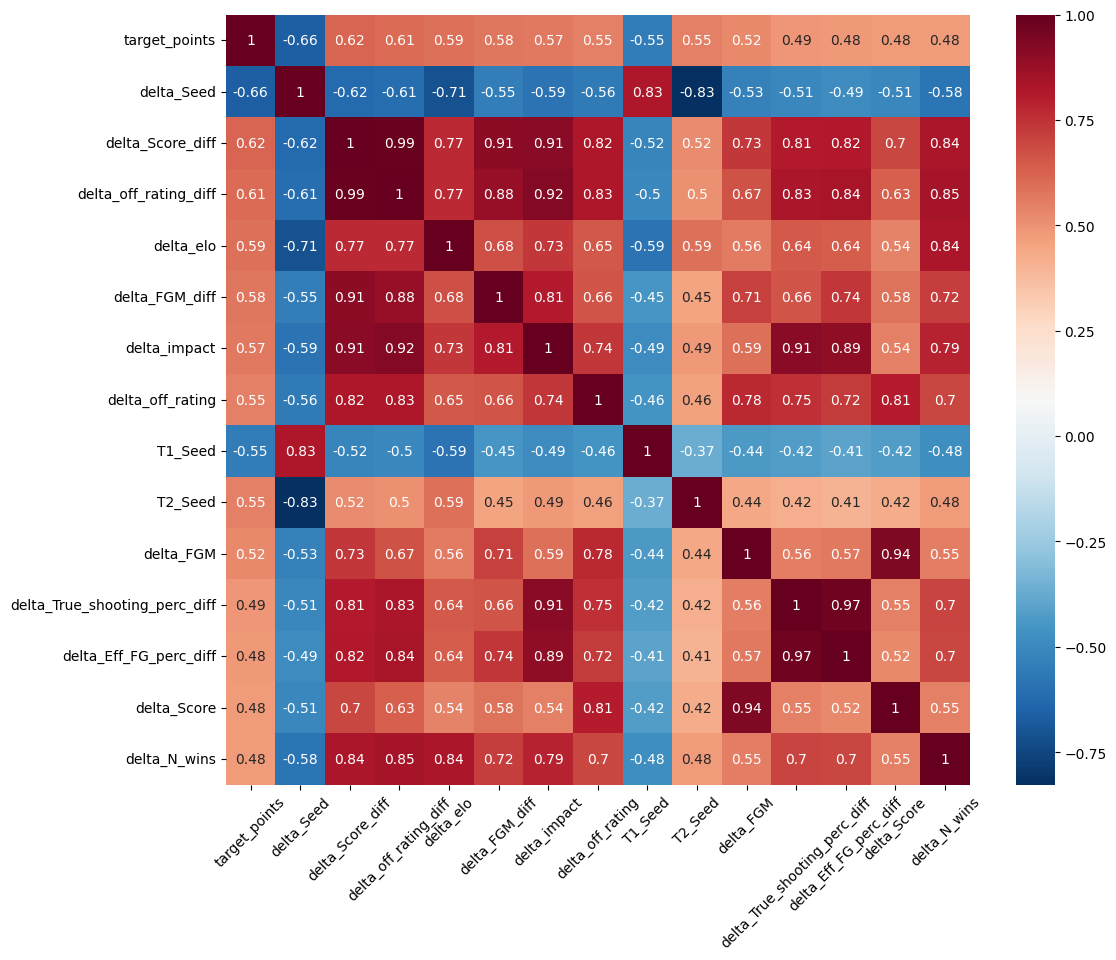

In [7]:
high_corr = tml.plot_correlations(data=df, target=target, limit=15, annot=True)

In [ ]:
tml.corr_target(data=df, target=target, cols=[c for c in high_corr.index if c != target], x_estimator=np.mean)

                               delta_Seed  delta_Score_diff  \
delta_Seed                       1.000000         -0.624785   
delta_Score_diff                -0.624785          1.000000   
delta_off_rating_diff           -0.608331          0.989949   
delta_elo                       -0.710626          0.766170   
delta_FGM_diff                  -0.545690          0.905482   
delta_impact                    -0.587713          0.908673   
delta_off_rating                -0.559344          0.824910   
T1_Seed                          0.827021         -0.516710   
T2_Seed                         -0.827021          0.516710   
delta_FGM                       -0.530631          0.729695   
delta_True_shooting_perc_diff   -0.508980          0.812995   
delta_Eff_FG_perc_diff          -0.490761          0.817186   
delta_Score                     -0.511267          0.695835   
delta_N_wins                    -0.577771          0.835065   
target_points                   -0.664030          0.61